C:\Users\laank\AppData\Local\Temp\ipykernel_21584\2516447705.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(csv_files))


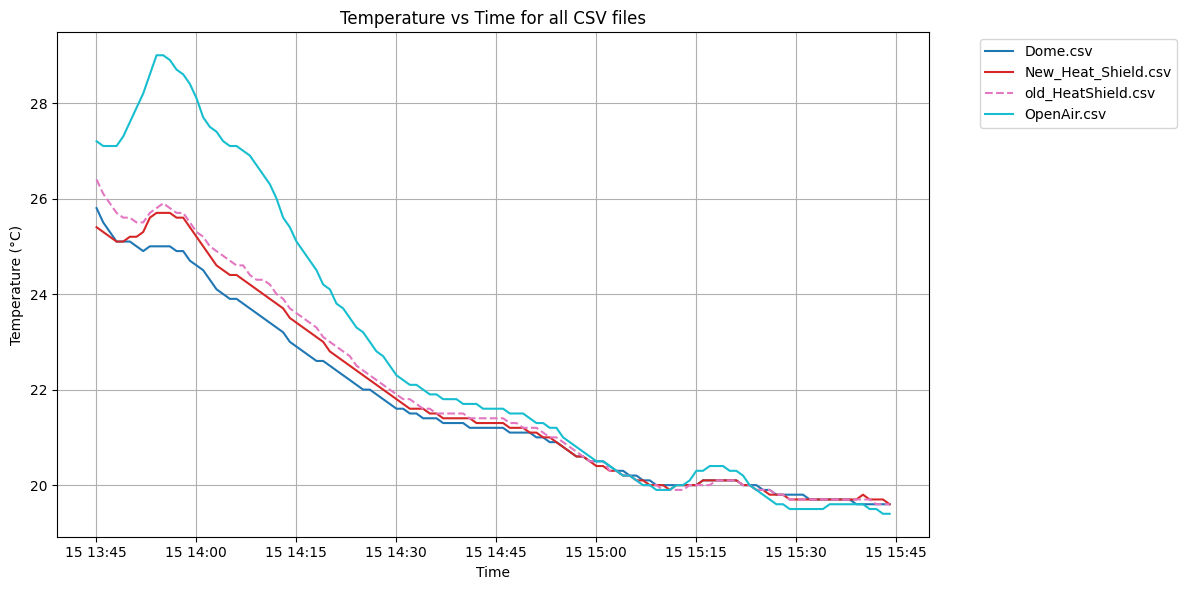

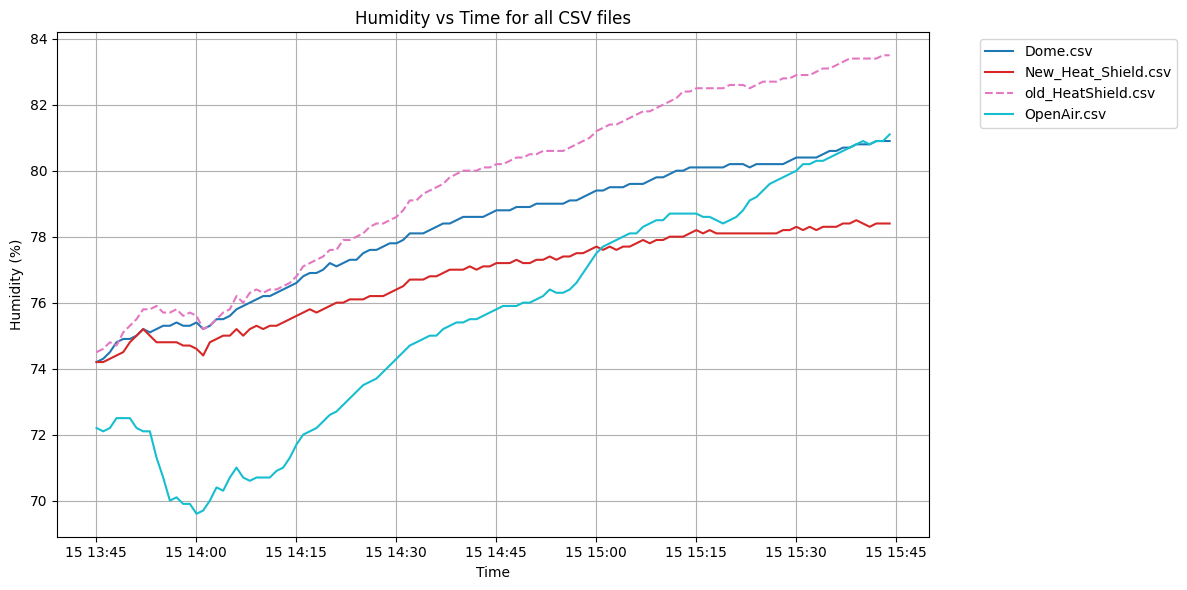

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob

csv_files = glob.glob("*.csv")

# csv_files = ['BIg Collin A.csv', 'Big Dome G.csv', 'Inside J.csv', 'Jelly Fish I.csv', 'Johannes C.csv', 'Nothing B.csv']

colors = cm.get_cmap('tab10', len(csv_files))

special_styles = {
    2: '--', 
    4: '-.',   
    6: ':'     
}

# --- TEMPERATURE PLOT ---
plt.figure(figsize=(12,6))

for i, name in enumerate(csv_files):
    df = pd.read_csv(
        name, 
        sep=";", 
        decimal=",", 
        usecols=[0,1,2,3,4],  
        header=None,
        names=["ID", "Date", "Time", "Temp", "Humidity"]
    )
    
    df["Datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str), errors="coerce")
    
    style = special_styles.get(i, '-') 
    plt.plot(df["Datetime"], df["Temp"], label=name, color=colors(i), linestyle=style)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Temperature vs Time for all CSV files")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()


# --- HUMIDITY PLOT ---
plt.figure(figsize=(12,6))

for i, name in enumerate(csv_files):
    df = pd.read_csv(
        name, 
        sep= ';',
        decimal=",", 
        usecols=[0,1,2,3,4],  
        header=None,
        names=["ID", "Date", "Time", "Temp", "Humidity"]
    )
    
    df["Datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str), errors="coerce")
    
    style = special_styles.get(i, '-') 
    plt.plot(df["Datetime"], df["Humidity"], label=name, color=colors(i), linestyle=style)

plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.title("Humidity vs Time for all CSV files")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()
